# 🌫️ Air Quality Prediction: Learning From the Sky We Breathe

<p align="center">
😷 🌍 ☁️ 🛰️
</p>

### *The atmosphere carries more than clouds — it carries stories of climate, industry, cities, and human impact.*

Air pollution is often invisible to the eye, yet deeply visible in its consequences.

From hazy skylines to rising respiratory concerns, predicting air quality has become an increasingly important challenge in environmental data science.

This project explores the use of **Machine Learning for Air Quality Prediction**, leveraging atmospheric, meteorological, and satellite-derived measurements to estimate pollution levels.

### 🔬 Data Signals Used

The model learns from multiple environmental perspectives:

🌡️ **Weather Conditions** — temperature, humidity, atmospheric moisture  

🌬️ **Wind Dynamics** — speed, direction, and air movement patterns  

☁️ **Cloud & Aerosol Indicators** — optical depth, albedo, aerosol indexes  

🛰️ **Satellite Observations** — NO₂, CO, SO₂, O₃, and atmospheric measurements  

📅 **Temporal Patterns** — cyclical time features, seasonal behavior, engineered interactions

---

### 🧠 Machine Learning Pipeline

This project investigates several modeling strategies including:

✔️ Random Forests  

✔️ Extra Trees Ensembles  

✔️ Neural Networks (MLPRegressor)  

✔️ Weighted Ensembling  

✔️ Multi-Model Stacking Architectures

Along the way, experiments included:

- Feature Engineering
- Missing Value Handling
- Hyperparameter Optimization
- Cross Validation
- Ensemble Learning
- Neural-Tree Model Diversity

---

### 📈 Final Approach

The strongest performance emerged from combining **tree-based ensembles with neural models inside a stacking framework**, allowing diverse model behaviors to collaborate on prediction.

> *Not every signal comes from the ground.*  
> *Some are hidden in clouds, winds, chemistry… and patterns waiting to be learned.*

---

### ✨ Project Goal

To build a robust predictive pipeline while exploring practical machine learning workflows for **tabular environmental data** — from feature engineering to advanced ensemble techniques.

*Because understanding the air we breathe is more than a modeling problem — it is a data problem with human consequences.* 🌍

## 📦 Imports & Environment Setup

This notebook uses Python's data science ecosystem for data processing, visualization, preprocessing, model development, hyperparameter optimization, and ensemble learning.


In [3]:
import pandas as pd
import numpy as np
import optuna
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import StackingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler


## 📂 Data Loading

The training and test datasets are loaded using pandas. Initial inspection is performed to understand feature types, missing values, and dataset structure.


In [2]:
df=pd.read_csv('Downloads/Train (3).csv')
test=pd.read_csv('Downloads/Test (2).csv')

## 🔍 Dataset Overview

Before modeling, the dataset structure is examined to identify:

* feature types
* object / numeric columns
* missing values
* target variable availability

Understanding the schema early helps guide preprocessing and feature engineering decisions.


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30557 entries, 0 to 30556
Data columns (total 82 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Place_ID X Date                                      30557 non-null  object 
 1   Date                                                 30557 non-null  object 
 2   Place_ID                                             30557 non-null  object 
 3   target                                               30557 non-null  float64
 4   target_min                                           30557 non-null  float64
 5   target_max                                           30557 non-null  float64
 6   target_variance                                      30557 non-null  float64
 7   target_count                                         30557 non-null  int64  
 8   precipitable_water_entire_atmosphere                 30557 non-nul

## ⚙️ Feature Engineering

Feature engineering was performed to enrich the environmental and temporal signals available to the models.

Additional variables were created from:

* temporal information extracted from dates
* cyclical month encoding
* weather interactions
* wind-related transformations
* humidity-based derived features

Some feature engineering ideas, experimentation, and conceptual exploration were developed iteratively with assistance from ChatGPT during the learning and experimentation process.

The goal was not blind feature generation, but testing whether engineered relationships could improve predictive performance.


In [4]:
df['Date'] = pd.to_datetime(
    df['Date']
)

df['month'] = df['Date'].dt.month

df['year'] = df['Date'].dt.year

df['day_of_week'] = df['Date'].dt.dayofweek

df['quarter'] = df['Date'].dt.quarter

df['week_of_year'] = df['Date'].apply(
    lambda x:x.isocalendar()[1]
)

df['is_weekend'] = (

    df['day_of_week']>=5

).astype(int)


df['month_sin'] = np.sin(

    2*np.pi*df['month']/12
)

df['month_cos'] = np.cos(

    2*np.pi*df['month']/12
)

df['wind_speed'] = np.sqrt(

    df[
        'u_component_of_wind_10m_above_ground'
    ]**2 +

    df[
        'v_component_of_wind_10m_above_ground'
    ]**2
)

df['wind_direction'] = np.arctan2(

    df[
        'v_component_of_wind_10m_above_ground'
    ],

    df[
        'u_component_of_wind_10m_above_ground'
    ]
)

df['temp_humidity_interaction'] = (

    df[
        'temperature_2m_above_ground'
    ]

    *

    df[
        'relative_humidity_2m_above_ground'
    ]
)

df['humidity_gap']=(
    
    df['relative_humidity_2m_above_ground']

    -

    df['specific_humidity_2m_above_ground']
)

In [5]:
test['Date'] = pd.to_datetime(
    test['Date']
)

test['month'] = test['Date'].dt.month

test['year'] = test['Date'].dt.year

test['day_of_week'] = test['Date'].dt.dayofweek

test['quarter'] = test['Date'].dt.quarter

test['week_of_year'] = test['Date'].apply(
    lambda x:x.isocalendar()[1]
)

test['is_weekend'] = (

    test['day_of_week']>=5

).astype(int)


test['month_sin'] = np.sin(

    2*np.pi*test['month']/12
)

test['month_cos'] = np.cos(

    2*np.pi*test['month']/12
)

test['wind_speed'] = np.sqrt(

    test[
        'u_component_of_wind_10m_above_ground'
    ]**2 +

    test[
        'v_component_of_wind_10m_above_ground'
    ]**2
)

test['wind_direction'] = np.arctan2(

    test[
        'v_component_of_wind_10m_above_ground'
    ],

    test[
        'u_component_of_wind_10m_above_ground'
    ]
)

test['temp_humidity_interaction'] = (

    test[
        'temperature_2m_above_ground'
    ]

    *

    test[
        'relative_humidity_2m_above_ground'
    ]
)


test['humidity_gap']=(
    
    test['relative_humidity_2m_above_ground']

    -

    test['specific_humidity_2m_above_ground'])



## 🧹 Missing Value Handling

Several atmospheric and satellite variables contain missing observations.

Median imputation was applied to numeric features to create a consistent modeling input while preserving robustness against outliers.


In [6]:
num_cols=df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col]=df[col].fillna(df[col].median())

## 🎯 Feature Selection

The final feature set combines:

* weather variables
* atmospheric measurements
* satellite-derived pollution indicators
* temporal encodings
* engineered environmental interactions

Feature inclusion evolved through iterative experimentation and model evaluation.


In [10]:
features = [

    # WEATHER

    'temperature_2m_above_ground',

    'relative_humidity_2m_above_ground',

    'specific_humidity_2m_above_ground',

    'precipitable_water_entire_atmosphere',
    
      
    
    

    # WIND

    'u_component_of_wind_10m_above_ground',

    'v_component_of_wind_10m_above_ground',

    'wind_speed',

    'wind_direction',

    # GASES

    'L3_NO2_NO2_column_number_density',

    'L3_CO_CO_column_number_density',

    'L3_SO2_SO2_column_number_density',

    'L3_O3_O3_column_number_density',
     
    'L3_O3_cloud_fraction',
    
    'L3_CLOUD_surface_albedo',

    

    'L3_CLOUD_cloud_top_height',
    
    'L3_CLOUD_cloud_optical_depth',

    'L3_AER_AI_absorbing_aerosol_index',

    'L3_CH4_aerosol_optical_depth',

    'L3_NO2_tropopause_pressure',

  

    'L3_O3_sensor_zenith_angle',

    'L3_NO2_solar_zenith_angle',

    'L3_O3_solar_zenith_angle',

    
   
    'L3_NO2_cloud_fraction',

    
    
    'L3_NO2_sensor_altitude',

    'L3_NO2_sensor_azimuth_angle',

   

    
'L3_SO2_SO2_column_number_density_amf',


'L3_SO2_absorbing_aerosol_index',

'L3_SO2_cloud_fraction',

'L3_SO2_sensor_azimuth_angle',

'L3_SO2_sensor_zenith_angle',


    
'L3_AER_AI_sensor_altitude',

'L3_AER_AI_sensor_azimuth_angle',

'L3_AER_AI_sensor_zenith_angle',

'L3_AER_AI_solar_azimuth_angle',

'L3_AER_AI_solar_zenith_angle',

    'L3_NO2_tropospheric_NO2_column_number_density',

    'L3_CO_H2O_column_number_density',

'L3_HCHO_tropospheric_HCHO_column_number_density',

'L3_HCHO_tropospheric_HCHO_column_number_density_amf',

'L3_CH4_CH4_column_volume_mixing_ratio_dry_air',

'L3_O3_O3_effective_temperature',

    'L3_CLOUD_cloud_base_pressure',

'L3_CLOUD_cloud_top_pressure',
    
    'L3_HCHO_HCHO_slant_column_number_density',

'L3_SO2_SO2_slant_column_number_density',

'L3_CH4_aerosol_height',


     # TIME FEATURES

    'month',

    # 'day_of_week',

    # 'is_weekend',

    # 'quarter',

    'month_sin',

    'month_cos',

    # ENGINEERED

    'temp_humidity_interaction',
    
    'humidity_gap',
    
]

## 🔀 Train / Validation Split

The dataset is divided into training and validation subsets to evaluate model generalization performance.

Median imputation is fitted on the training feature space and applied consistently during preprocessing.


In [11]:
X=df[features]
y=df['target']

In [36]:
imputer=SimpleImputer(
    strategy='median'
)

X_imputed=imputer.fit_transform(
    X
)

X_test_imputed = imputer.transform(test[features])

In [14]:
X_train,X_val,y_train,y_val=train_test_split(X_imputed,y,test_size=0.2,random_state=42)

## 🌲 Random Forest Regressor

A tuned Random Forest model was trained as one of the primary tree-based baselines.

Hyperparameters were selected through iterative experimentation and Optuna-based exploration.

In [2]:
st_rf_model = RandomForestRegressor(
    n_estimators=800,
    max_depth=40,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)

st_rf_model.fit(
    X_train,
    y_train
);

In [102]:
rf_preds = st_rf_model.predict(
    X_val
)

C:\Users\DELL\AppData\Local\Temp\ipykernel_18132\3750978675.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


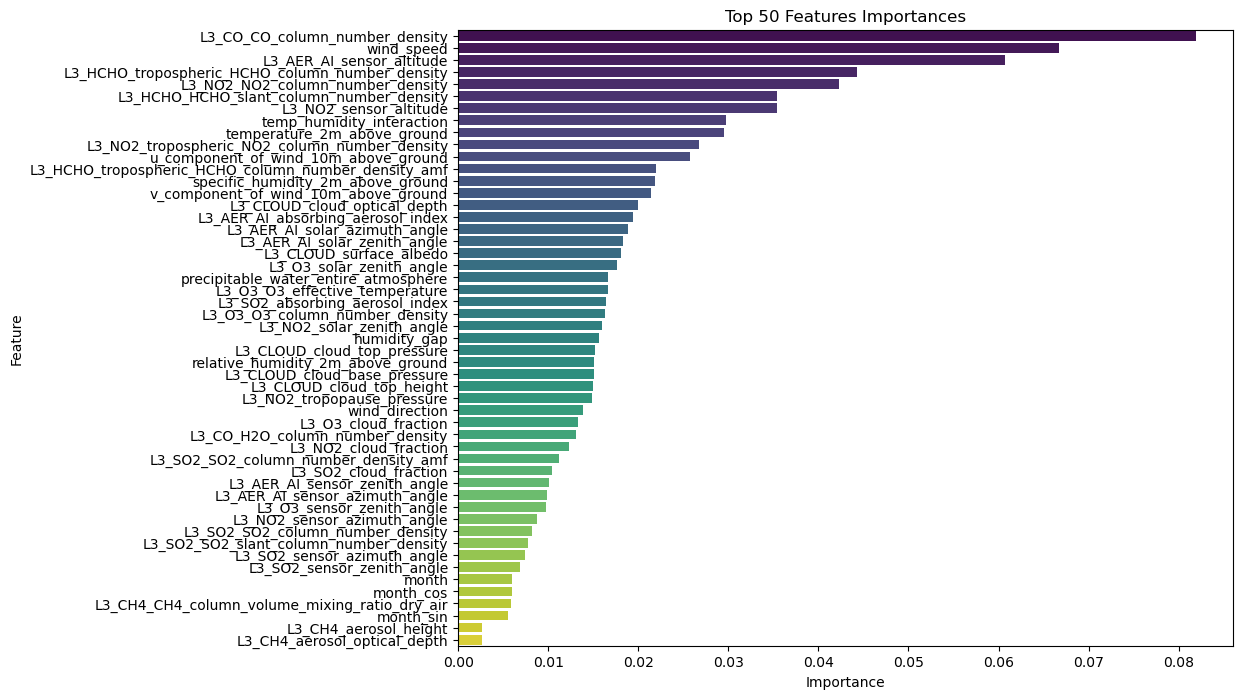

In [63]:
importance=pd.DataFrame({
    'Feature':features,
    'Importance':
    best_model.feature_importances_
                        
})

importance=importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,8))
sns.barplot(
    data=importance.head(60),
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title(
    'Top 50 Features Importances'
)
plt.show()

### 📊 Feature Importance Analysis

Tree-based models provide native feature importance estimates, helping interpret which environmental and atmospheric variables most influenced predictions.

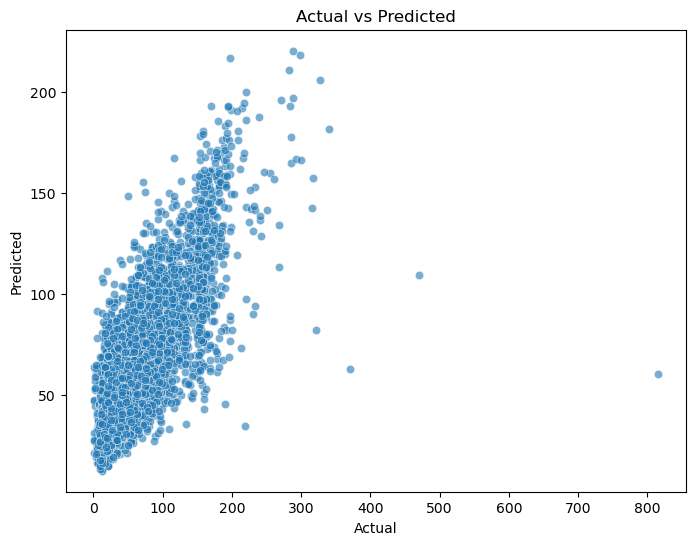

In [64]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=y_val,
    y=y_pred,
    alpha=0.6
)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(
    'Actual vs Predicted'
)
plt.show()

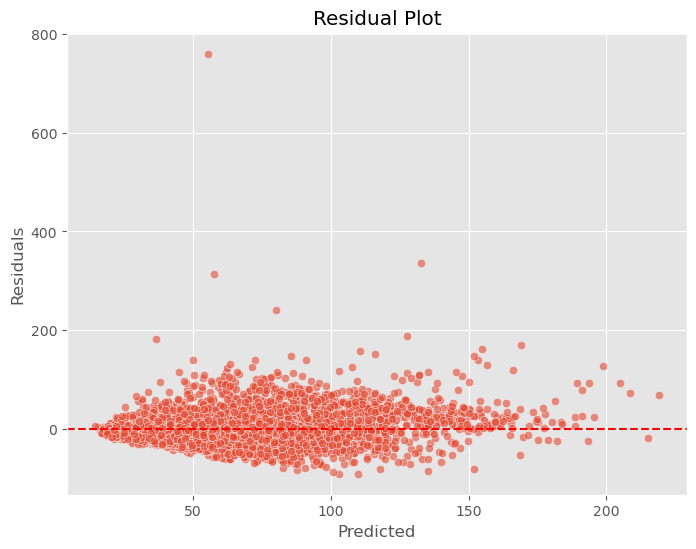

In [232]:
residuals=y_val-y_pred
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=y_pred,
    y=residuals,
    alpha=0.6
)
plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

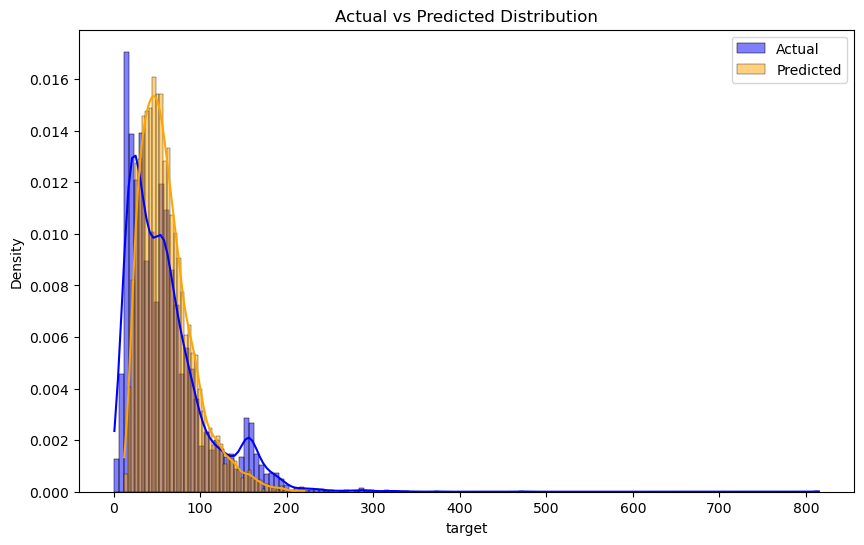

In [65]:
plt.figure(figsize=(10,6))

sns.histplot(

    y_val,

    color='blue',

    label='Actual',

    kde=True,

    stat='density'
)

sns.histplot(

    y_pred,

    color='orange',

    label='Predicted',

    kde=True,

    stat='density'
)

plt.legend()

plt.title(
    'Actual vs Predicted Distribution'
)

plt.show()

### 📈 Model Evaluation

Model behaviour was inspected using:

- Actual vs Predicted comparison
- Residual analysis
- Distribution comparison between true and predicted targets

These visual diagnostics help assess calibration, bias, variance, and prediction spread.

## 🌳 Extra Trees Regressor

Extra Trees was explored as a second ensemble learner.

Compared with Random Forest, Extra Trees introduces additional randomness during tree construction, sometimes improving generalization on tabular datasets.

In [ ]:
st_et_model = ExtraTreesRegressor(
    n_estimators=700, 
    max_depth=25,
    min_samples_split=2,
    min_samples_leaf=1, 
    max_features=None, 
    bootstrap=False,
    random_state=1,
    n_jobs=-1
)

st_et_model.fit(
    X_train,
    y_train
)

In [104]:
et_preds = st_et_model.predict(
    X_val
)


In [33]:
et_importance=pd.DataFrame({
    'Features':features,
    'Importance':et_model.feature_importances_
})

In [34]:
et_importance=et_importance.sort_values(
    by='Importance',
    ascending=False
)

C:\Users\DELL\AppData\Local\Temp\ipykernel_18132\2571971332.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


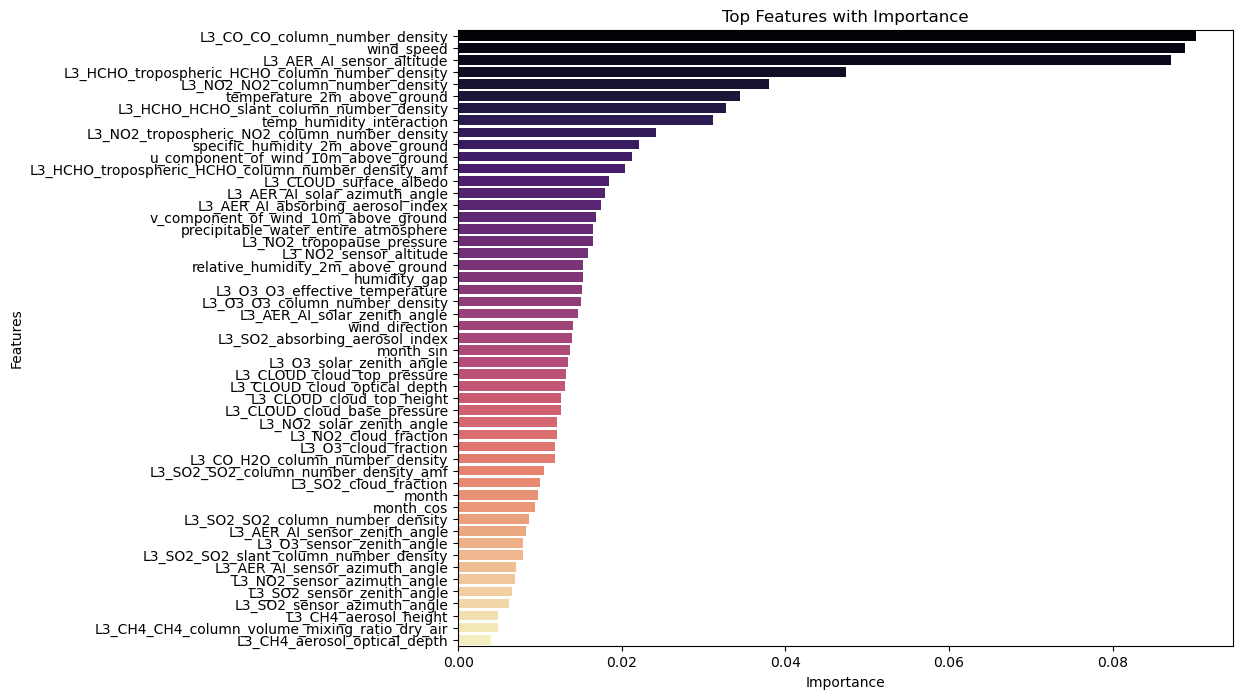

In [38]:

plt.figure(figsize=(10,8))
sns.barplot(
    data=et_importance.head(60),
    x='Importance',
    y='Features',
    palette='magma'
)
plt.title('Top Features with Importance')
plt.show()

## 🤝 Weighted Ensembling

Predictions from multiple models were combined using weighted averaging to explore whether complementary model behaviour could improve predictive performance.

In [88]:
ensemble_preds=0.8*preds+0.2*y_pred

In [89]:
rmse = np.sqrt(

    mean_squared_error(

        y_val,

        ensemble_preds
    )
)

print(
    'Ensemble RMSE:',
    rmse
)

Ensemble RMSE: 29.18826014559313


In [90]:
weights = [

0.1,

0.2,

0.3,

0.4,

0.5,

0.6,

0.7,

0.8,

0.9
]

In [92]:
for w in weights:

    ensemble = (

        w*preds

        +

        (1-w)*y_pred
    )

    rmse = np.sqrt(

        mean_squared_error(

            y_val,

            ensemble
        )
    )

    print(
        w,
        rmse
    )

0.1 29.603229306425142
0.2 29.52441858976344
0.3 29.45204496661028
0.4 29.38615599774463
0.5 29.326795390721024
0.6 29.274002859389302
0.7 29.22781399439128
0.8 29.18826014559313
0.9 29.155368317340635


## 🚀 Final Training on Full Dataset

After validation experiments, the strongest models were retrained using the complete training dataset before generating final competition predictions.

This step allows the models to learn from all available observations.

In [ ]:
best_model.fit(X_imputed,y)

In [ ]:
et_model.fit(X_imputed,y)

In [ ]:
rf_preds=best_model.predict(test[features])

In [ ]:
et_preds=et_model.predict(test[features])

## ⚙️ Final Model Configurations

The final model configurations below reflect the best-performing hyperparameter combinations discovered during experimentation and tuning.

In [17]:
best_rf=RandomForestRegressor(

    n_estimators=800,
    max_depth=40,
    min_samples_split=2,
    min_samples_leaf=1, 
    max_features='sqrt',
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)
best_et = ExtraTreesRegressor(
    n_estimators=700, 
    max_depth=25,
    min_samples_split=2,
    min_samples_leaf=1, 
    max_features=None, 
    bootstrap=False,
    random_state=1,
    n_jobs=-1
)

## 🧠 Neural Network Experiment

A simple neural network regressor was tested as an experimental baseline.

The architecture used standard scaling followed by a multilayer perceptron (MLP).

Although performance did not surpass tree-based ensembles, the experiment was retained for comparison and learning purposes.

In [25]:
nn=Pipeline([
    ('scaler',
    StandardScaler()),

    ('mlp',
    MLPRegressor(
        hidden_layer_sizes=(128,64),

        activation='relu',

        alpha=0.001,

        learning_rate='adaptive',

        max_iter=500,

        random_state=42

        
    ))
])

In [ ]:
nn.fit(X_train,y_train)

In [27]:
preds=nn.predict(X_val)

In [28]:
rmse = np.sqrt(

    mean_squared_error(

        y_val,

        preds
    )
)

print(
    "NN RMSE:",
    rmse
)

NN RMSE: 33.84965466985578


## 🏆 Stacked Ensemble Model

A stacking ensemble was constructed by combining:

- Random Forest
- Extra Trees
- Neural Network (MLP)

A Linear Regression meta-learner was used to learn how to optimally combine predictions from the base learners.

This approach achieved the strongest validation performance in the project.

In [29]:
stack = StackingRegressor(

    estimators=[

        ('rf',best_rf),

        ('et',best_et),

        ('nn',nn)

    ],

    final_estimator=LinearRegression(),

    cv=3,

    n_jobs=-1
)

stack.fit(
    X_train,
    y_train
)

preds = stack.predict(
    X_val
)

In [30]:
rmse = np.sqrt(

    mean_squared_error(

        y_val,

        preds
    )
)

print(rmse)

28.20257783725832


In [31]:
stack.fit(
    X_imputed,
    y
)

StackingRegressor(cv=3,
                  estimators=[('rf',
                               RandomForestRegressor(bootstrap=False,
                                                     max_depth=40,
                                                     max_features='sqrt',
                                                     n_estimators=800,
                                                     n_jobs=-1,
                                                     random_state=42)),
                              ('et',
                               ExtraTreesRegressor(max_depth=25,
                                                   max_features=None,
                                                   n_estimators=700, n_jobs=-1,
                                                   random_state=1)),
                              ('nn',
                               Pipeline(steps=[('scaler', StandardScaler()),
                                               ('mlp',
                                                MLPRegressor(alpha=0.001,
                                                             hidden_layer_sizes=(128,
                                                                                 64),
                                                             learning_rate='adaptive',
                                                             max_iter=500,
                                                             random_state=42))]))],
                  final_estimator=LinearRegression(), n_jobs=-1)

## 📦 Submission Generation

The final stacked model was retrained using the complete dataset.

Predictions were generated for the competition test set and exported into submission format.

In [38]:
test_preds = stack.predict(X_test_imputed)



submission = pd.DataFrame({
    'Place_ID X Date': test['Place_ID X Date'],
    'target': test_preds
})

submission.to_csv('submission.csv', index=False)

## 🏁 Project Conclusion

This project explored machine learning approaches for predicting urban air pollution using atmospheric, meteorological, and satellite-derived variables.

Throughout the experimentation process, multiple techniques were tested, including:

* Random Forest Regressor
* Extra Trees Regressor
* Neural Network (MLP)
* Weighted Ensembling
* Stacked Ensemble Learning

Feature engineering included temporal, cyclical, and interaction-based features to enrich the original dataset. Hyperparameter tuning was performed through iterative experimentation and Optuna-based searches.

### Final Performance Summary

| Model             | Validation RMSE  |
| ----------------- | ---------------- |
| Random Forest     | *(your RF RMSE)* |
| Extra Trees       | *(your ET RMSE)* |
| Neural Network    | **33.85**        |
| Weighted Ensemble | **~29.15**       |
| Stacked Ensemble  | **28.20** ⭐      |

### Competition Result

**Public Test RMSE:** **32.38838244**
**Current Leaderboard Rank:** **133 / 588**

The stacked ensemble produced the strongest validation performance and was selected as the final submission model.

This project was completed as part of my machine learning learning journey, combining experimentation, independent reasoning, iterative debugging, and collaborative brainstorming with ChatGPT during feature engineering and modeling discussions.

Overall, the project strengthened my understanding of:

* Feature Engineering
* Tree-Based Ensemble Models
* Hyperparameter Tuning
* Ensembling & Stacking
* Model Evaluation & Error Analysis
* Practical ML Competition Workflows
